In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.listdir('/content/drive/MyDrive/Colab')

['placement_dataset.csv',
 'placement_predict_50k Dataset (1) (1).csv',
 'placement_predict_50k_adjusted.csv',
 'age_insurance.csv',
 'simple_placement_dataset.csv',
 'movies_dataset(1).csv',
 'WineQT.csv',
 'WineQT_Feature_Engineered.csv',
 'placement_predict_50k_adjusted (1).csv',
 'student_data.csv',
 'xgboost_lightgbm_shap_student_dataset.csv',
 'iris_dataset.csv',
 'breast_cancer_classification_dataset (1).csv',
 'mall_customers_clustering_dataset.csv',
 'digits_pca_tsne_umap_dataset.csv',
 'isolation_forest_dataset.csv',
 'socioeconomic_profiling_dataset.csv',
 'ml_cross_validation_calibration_dataset.csv',
 'hyperparameter_tuning_dataset.csv',
 'evaluation_threshold_calibration_dataset.csv',
 'student_performance.csv',
 'student_performance_mlops.csv',
 'dimensionality_reduction_anomaly_detection_dataset.csv']

In [3]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab/placement_dataset.csv')

First 5 rows:
  Student_ID  Study_Hours  Sleep_Hours  Attendance_Percentage  \
0       S001        40.41        24.15                  70.70   
1       S002        39.65        25.40                  62.68   
2       S003        45.94        24.32                  70.12   
3       S004        41.84        35.31                  72.90   
4       S005        55.45        34.61                  80.93   

   Assignment_Score  Exam_Score  Screen_Time_Hours Actual_Status  
0             43.63       56.73              24.61        Normal  
1             28.64       39.94              23.33        Normal  
2             19.10       71.62              37.10        Normal  
3             51.85       77.54              44.43        Normal  
4             35.33       64.54              33.47        Normal  

Dataset shape: (500, 8)

Missing values:
Student_ID               0
Study_Hours              0
Sleep_Hours              0
Attendance_Percentage    0
Assignment_Score         0
Exam_Score      

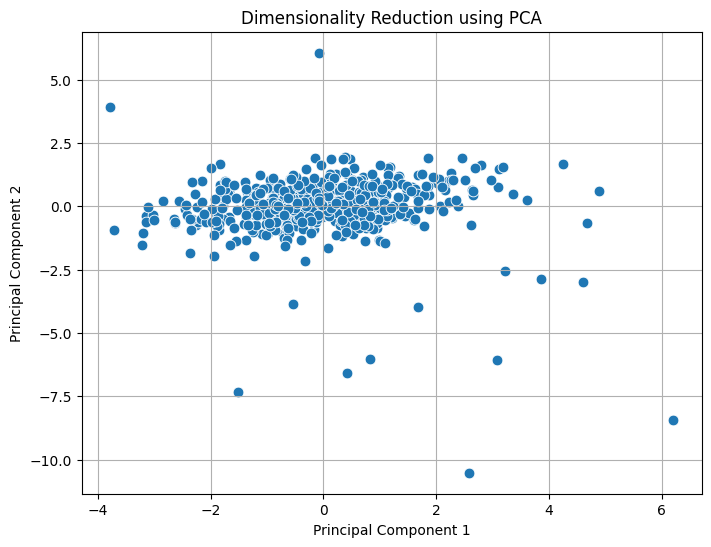


Detected anomalies:
    Student_ID Detected_Status  Anomaly_Score
480       S481         Anomaly      -0.233132
481       S482         Anomaly      -0.168359
482       S483         Anomaly      -0.169185
483       S484         Anomaly      -0.250138
484       S485         Anomaly      -0.211609
485       S486         Anomaly      -0.224767
486       S487         Anomaly      -0.203468
487       S488         Anomaly      -0.111966
488       S489         Anomaly      -0.054102
489       S490         Anomaly      -0.099057
490       S491         Anomaly      -0.108368
491       S492         Anomaly      -0.184042
492       S493         Anomaly      -0.085183
493       S494         Anomaly      -0.149122
494       S495         Anomaly      -0.188658
495       S496         Anomaly      -0.061371
496       S497         Anomaly      -0.089443
497       S498         Anomaly      -0.066036
498       S499         Anomaly      -0.149549
499       S500         Anomaly      -0.151789


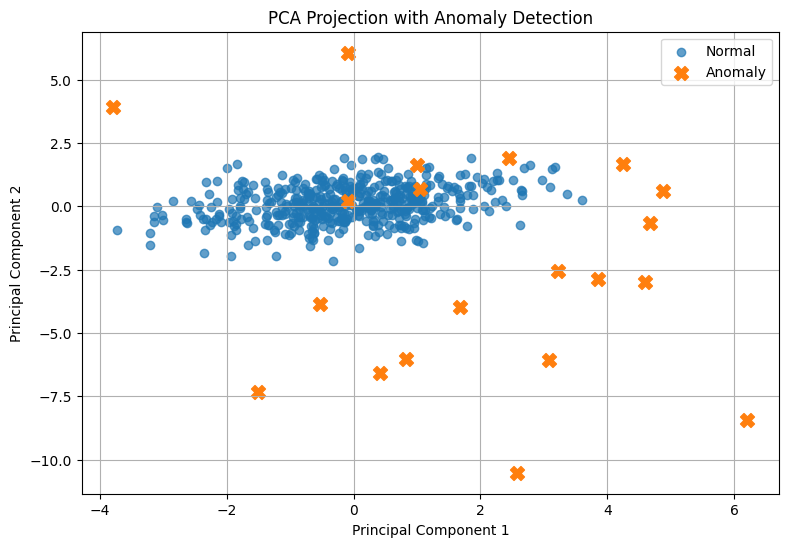


Confusion Matrix:
[[480   0]
 [  0  20]]

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       480
     Anomaly       1.00      1.00      1.00        20

    accuracy                           1.00       500
   macro avg       1.00      1.00      1.00       500
weighted avg       1.00      1.00      1.00       500


Completed successfully.
Results saved as anomaly_detection_results.csv


In [5]:
# Dimensionality Reduction and Anomaly Detection
# Machine Learning Project

# Install if required:
# pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, classification_report

# -------------------------------------------------
# 1. Load dataset
# -------------------------------------------------
df = pd.read_csv('/content/drive/MyDrive/Colab/dimensionality_reduction_anomaly_detection_dataset.csv')

print("First 5 rows:")
print(df.head())

print("\nDataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

# Actual_Status is included only because this is a synthetic
# teaching dataset. It is NOT used to train the anomaly detector.
feature_columns = [
    "Study_Hours",
    "Sleep_Hours",
    "Attendance_Percentage",
    "Assignment_Score",
    "Exam_Score",
    "Screen_Time_Hours"
]

X = df[feature_columns]

# -------------------------------------------------
# 2. Standardize the features
# -------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------------------------
# 3. Dimensionality Reduction using PCA
# -------------------------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("\nExplained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal variance retained:",
      pca.explained_variance_ratio_.sum())

# Create PCA dataframe
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Student_ID"] = df["Student_ID"]

# -------------------------------------------------
# 4. Visualize PCA result
# -------------------------------------------------
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x="PC1",
    y="PC2",
    data=pca_df,
    s=60
)
plt.title("Dimensionality Reduction using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

# -------------------------------------------------
# 5. Anomaly Detection using Isolation Forest
# -------------------------------------------------
model = IsolationForest(
    n_estimators=100,
    contamination=0.04,
    random_state=42
)

predictions = model.fit_predict(X_scaled)

# Isolation Forest:
#  1  = normal
# -1  = anomaly

df["Prediction"] = predictions
df["Detected_Status"] = df["Prediction"].map({
    1: "Normal",
    -1: "Anomaly"
})

# Anomaly score
df["Anomaly_Score"] = model.decision_function(X_scaled)

print("\nDetected anomalies:")
print(
    df[df["Detected_Status"] == "Anomaly"][
        ["Student_ID", "Detected_Status", "Anomaly_Score"]
    ]
)

# -------------------------------------------------
# 6. PCA visualization with detected anomalies
# -------------------------------------------------
pca_df["Detected_Status"] = df["Detected_Status"]

plt.figure(figsize=(9, 6))

normal_points = pca_df[pca_df["Detected_Status"] == "Normal"]
anomaly_points = pca_df[pca_df["Detected_Status"] == "Anomaly"]

plt.scatter(
    normal_points["PC1"],
    normal_points["PC2"],
    label="Normal",
    alpha=0.7
)

plt.scatter(
    anomaly_points["PC1"],
    anomaly_points["PC2"],
    label="Anomaly",
    marker="X",
    s=100
)

plt.title("PCA Projection with Anomaly Detection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------------------------
# 7. Evaluate using the known synthetic labels
# -------------------------------------------------
# This section is ONLY for evaluating the generated
# teaching dataset. In a real unlabeled dataset,
# Actual_Status would normally not be available.

y_true = (df["Actual_Status"] == "Anomaly").astype(int)
y_pred = (df["Detected_Status"] == "Anomaly").astype(int)

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=["Normal", "Anomaly"]
))

# -------------------------------------------------
# 8. Save final results
# -------------------------------------------------
df.to_csv(
    "anomaly_detection_results.csv",
    index=False
)

print("\nCompleted successfully.")
print("Results saved as anomaly_detection_results.csv")
